In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import seaborn as sns
import shap

sys.path.append(os.path.abspath('..'))
from src.lstm_encoder import HybridCNNBiLSTMEncoder

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Executing Phase 19 XAI on: {device}")

# 1. Load Dataset B (12-channel sliding-window arrays)
data_path = Path('../data/processed_downstream/fdi_feeder_windows.npz')
data = np.load(data_path)

X_train, y_train = data['X_train'], data['y_train']
X_test, y_test   = data['X_test'],  data['y_test']
feature_names    = list(data['feature_names'])

print(f"Loaded Test Set: {X_test.shape} windows")
print(f"12 Channel Telemetry Features: {feature_names}")

# 2. Define and Load Model A (Scratch Baseline Model with highest discriminative fidelity)
class ScratchFDIModel(nn.Module):
    def __init__(self, in_channels=12, cnn_hidden_dims=(64, 128), lstm_hidden_dim=128, mlp_hidden_dim=64):
        super().__init__()
        self.encoder = HybridCNNBiLSTMEncoder(
            in_channels=in_channels,
            cnn_hidden_dims=cnn_hidden_dims,
            lstm_hidden_dim=lstm_hidden_dim,
            lstm_layers=2,
            pool_strategy="mean"
        )
        self.mlp_head = nn.Sequential(
            nn.Linear(self.encoder.out_dim, mlp_hidden_dim),
            nn.BatchNorm1d(mlp_hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(mlp_hidden_dim, 1)
        )

    def forward(self, x):
        h = self.encoder(x, return_sequence=False)
        return self.mlp_head(h)

model = ScratchFDIModel().to(device)
model_path = Path('../saved_models/exp_model_scratch_best.pth')
assert model_path.exists(), f"Model checkpoint missing at: {model_path}"
model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
model.eval()
print(f"[SUCCESS] Loaded Model Checkpoint from {model_path}")

Executing Phase 19 XAI on: cuda
Loaded Test Set: (1052, 30, 12) windows
12 Channel Telemetry Features: [np.str_('12 kV Feeder_voltage_kV'), np.str_('12 kV Feeder_current_A'), np.str_('12 kV Feeder_frequency_Hz'), np.str_('3 kV Feeder_voltage_kV'), np.str_('3 kV Feeder_current_A'), np.str_('3 kV Feeder_frequency_Hz'), np.str_('5 kV Feeder_voltage_kV'), np.str_('5 kV Feeder_current_A'), np.str_('5 kV Feeder_frequency_Hz'), np.str_('8 kV Feeder_voltage_kV'), np.str_('8 kV Feeder_current_A'), np.str_('8 kV Feeder_frequency_Hz')]
[SUCCESS] Loaded Model Checkpoint from ..\saved_models\exp_model_scratch_best.pth


In [3]:
# Cell 2: Configure SHAP GradientExplainer (cuDNN-Compatible)
import shap
import torch
import torch.nn as nn
import numpy as np

# 1. Disable cuDNN to allow backward gradient propagation through BiLSTM in eval mode
torch.backends.cudnn.enabled = False

# 2. Select representative background samples (normal baseline) from training data
np.random.seed(42)
normal_idx = np.where(y_train == 0)[0]
background_idx = np.random.choice(normal_idx, size=100, replace=False)
background_tensor = torch.from_numpy(X_train[background_idx]).to(device)

# 3. Select balanced test instances: 50 confirmed Attacks and 50 confirmed Normal
attack_test_idx = np.where(y_test == 1)[0][:50]
normal_test_idx = np.where(y_test == 0)[0][:50]
eval_indices = np.concatenate([attack_test_idx, normal_test_idx])

eval_tensor = torch.from_numpy(X_test[eval_indices]).to(device)
eval_labels = y_test[eval_indices]

print(f"Background distribution: {background_tensor.shape} (100 baseline windows)")
print(f"Evaluation instances:    {eval_tensor.shape} (50 FDI Attacks, 50 Normal)")

# 4. Wrapper model returning probability [0, 1]
class ModelProbWrapper(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model
        
    def forward(self, x):
        logits = self.base_model(x)
        return torch.sigmoid(logits)

prob_model = ModelProbWrapper(model).to(device)
prob_model.eval()

# 5. Compute SHAP Values using GradientExplainer
explainer = shap.GradientExplainer(prob_model, background_tensor)
shap_values = explainer.shap_values(eval_tensor)

# Re-enable cuDNN after SHAP gradient calculation
torch.backends.cudnn.enabled = True

# Format output as numpy array (N, 30, 12)
if isinstance(shap_values, list):
    shap_values = shap_values[0]
if isinstance(shap_values, torch.Tensor):
    shap_values = shap_values.cpu().numpy()

print(f"[SUCCESS] Calculated SHAP Tensor Shape: {shap_values.shape} (Samples, Timesteps, Channels)")

Background distribution: torch.Size([100, 30, 12]) (100 baseline windows)
Evaluation instances:    torch.Size([100, 30, 12]) (50 FDI Attacks, 50 Normal)
[SUCCESS] Calculated SHAP Tensor Shape: (100, 30, 12, 1) (Samples, Timesteps, Channels)


PHASE 19: GLOBAL SENSOR IMPORTANCE (SHAP VALUE RANKING)
                  Feature       Feeder  Measurement  Mean_Abs_SHAP
    3 kV Feeder_current_A  3 kV Feeder    current_A       0.006846
 8 kV Feeder_frequency_Hz  8 kV Feeder frequency_Hz       0.006307
    8 kV Feeder_current_A  8 kV Feeder    current_A       0.004833
    5 kV Feeder_current_A  5 kV Feeder    current_A       0.004538
12 kV Feeder_frequency_Hz 12 kV Feeder frequency_Hz       0.004002
   12 kV Feeder_current_A 12 kV Feeder    current_A       0.003911
   8 kV Feeder_voltage_kV  8 kV Feeder   voltage_kV       0.001937
   3 kV Feeder_voltage_kV  3 kV Feeder   voltage_kV       0.001418
 3 kV Feeder_frequency_Hz  3 kV Feeder frequency_Hz       0.001300
   5 kV Feeder_voltage_kV  5 kV Feeder   voltage_kV       0.001238
 5 kV Feeder_frequency_Hz  5 kV Feeder frequency_Hz       0.000690
  12 kV Feeder_voltage_kV 12 kV Feeder   voltage_kV       0.000501


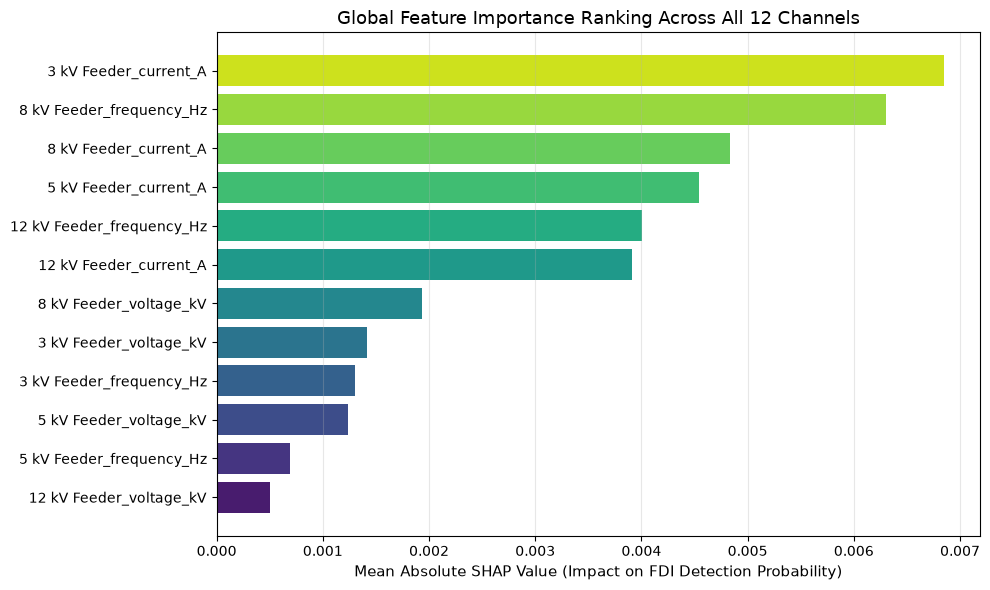

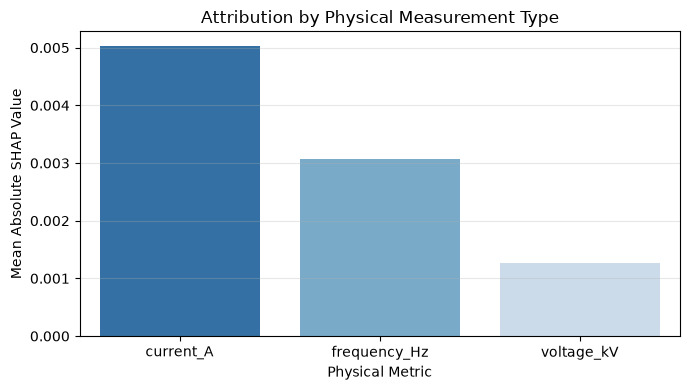

In [5]:
# Cell 3: Global Feature Importance Across Channels & Feeders (Fixed)
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

fig_dir = Path('../results/figures')
fig_dir.mkdir(parents=True, exist_ok=True)

# 1. Squeeze any singleton dimensions so shap_values is guaranteed to be (N, 30, 12)
shap_array = np.squeeze(np.array(shap_values))
if shap_array.ndim == 4:
    shap_array = shap_array[..., 0]

# Average across samples (axis 0) and timesteps (axis 1) -> shape (12,)
global_importance = np.mean(np.abs(shap_array), axis=(0, 1)).flatten()

# Ensure feature_names matches length 12
assert len(feature_names) == len(global_importance), f"Length mismatch: {len(feature_names)} vs {len(global_importance)}"

# 2. Construct clean DataFrame
df_importance = pd.DataFrame({
    'Feature': list(feature_names),
    'Feeder': [str(f).split('_')[0] for f in feature_names],
    'Measurement': ['_'.join(str(f).split('_')[1:]) for f in feature_names],
    'Mean_Abs_SHAP': global_importance
}).sort_values(by='Mean_Abs_SHAP', ascending=False).reset_index(drop=True)

print("=" * 65)
print("PHASE 19: GLOBAL SENSOR IMPORTANCE (SHAP VALUE RANKING)")
print("=" * 65)
print(df_importance.to_string(index=False))
print("=" * 65)

# Save table to CSV
results_dir = Path('../results')
results_dir.mkdir(parents=True, exist_ok=True)
df_importance.to_csv(results_dir / 'phase19_shap_feature_importance.csv', index=False)

# 3. Horizontal Bar Plot: Global Feature Importance
plt.figure(figsize=(10, 6))
palette = sns.color_palette("viridis", len(df_importance))
plt.barh(df_importance['Feature'][::-1], df_importance['Mean_Abs_SHAP'][::-1], color=palette)
plt.xlabel('Mean Absolute SHAP Value (Impact on FDI Detection Probability)', fontsize=11)
plt.title('Global Feature Importance Ranking Across All 12 Channels', fontsize=13)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir / 'phase19_shap_global_bar.png', dpi=300)
plt.show()

# 4. Grouped Attribution: By Physical Measurement Type
grouped_meas = df_importance.groupby('Measurement', as_index=False)['Mean_Abs_SHAP'].mean()

plt.figure(figsize=(7, 4))
sns.barplot(data=grouped_meas, x='Measurement', y='Mean_Abs_SHAP', hue='Measurement', legend=False, palette='Blues_r')
plt.title('Attribution by Physical Measurement Type', fontsize=12)
plt.ylabel('Mean Absolute SHAP Value')
plt.xlabel('Physical Metric')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir / 'phase19_shap_measurement_importance.png', dpi=300)
plt.show()

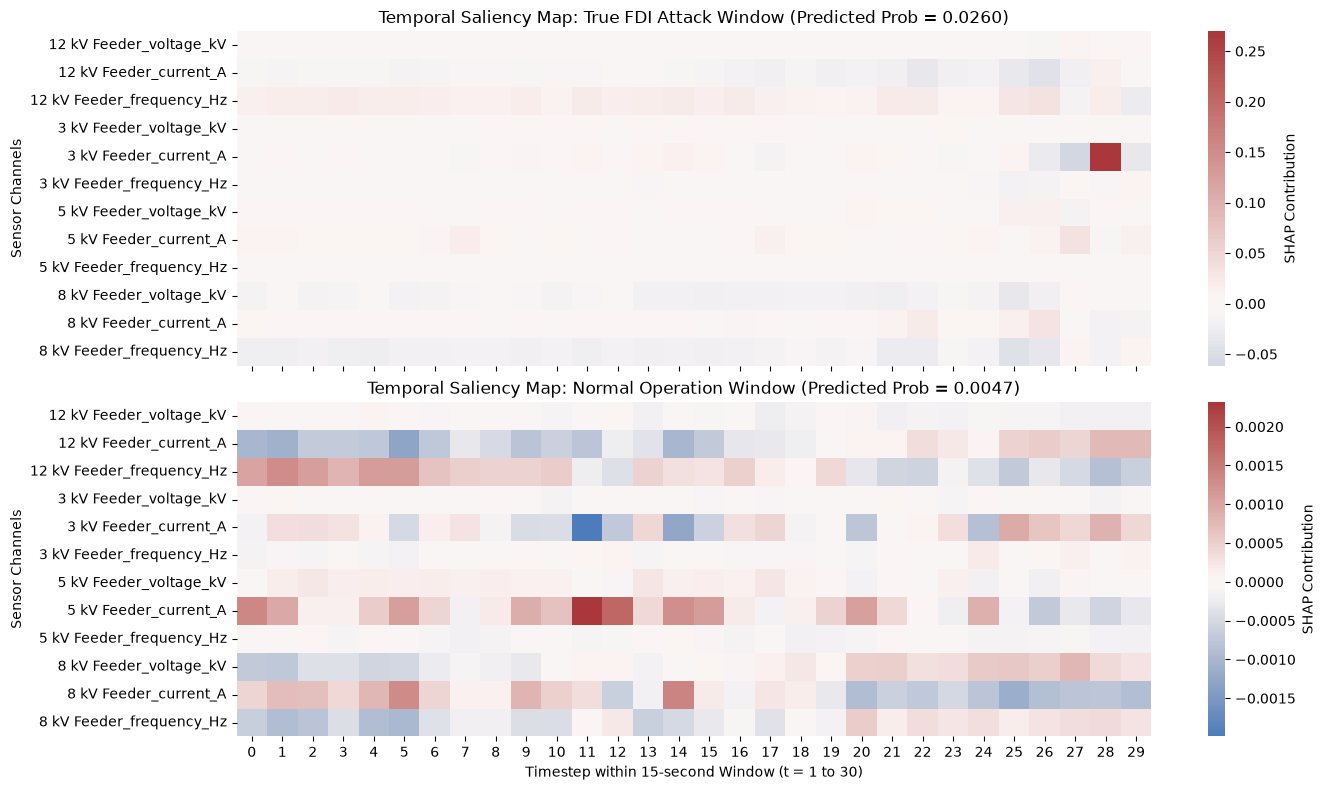

In [6]:
# Cell 4: Single-Instance Explanations (FDI Attack vs. Normal Window)
with torch.no_grad():
    probs = prob_model(eval_tensor).cpu().numpy().flatten()

attack_indices = np.where(eval_labels == 1)[0]
best_attack_idx = attack_indices[np.argmax(probs[attack_indices])]

normal_indices = np.where(eval_labels == 0)[0]
best_normal_idx = normal_indices[np.argmin(probs[normal_indices])]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Heatmap for True Positive FDI Attack
sns.heatmap(
    shap_array[best_attack_idx].T,
    cmap='vlag',
    center=0,
    ax=axes[0],
    yticklabels=feature_names,
    cbar_kws={'label': 'SHAP Contribution'}
)
axes[0].set_title(f'Temporal Saliency Map: True FDI Attack Window (Predicted Prob = {probs[best_attack_idx]:.4f})', fontsize=12)
axes[0].set_ylabel('Sensor Channels')

# Heatmap for True Negative Normal Window
sns.heatmap(
    shap_array[best_normal_idx].T,
    cmap='vlag',
    center=0,
    ax=axes[1],
    yticklabels=feature_names,
    cbar_kws={'label': 'SHAP Contribution'}
)
axes[1].set_title(f'Temporal Saliency Map: Normal Operation Window (Predicted Prob = {probs[best_normal_idx]:.4f})', fontsize=12)
axes[1].set_xlabel('Timestep within 15-second Window (t = 1 to 30)')
axes[1].set_ylabel('Sensor Channels')

plt.tight_layout()
plt.savefig(fig_dir / 'phase19_shap_temporal_saliency.png', dpi=300)
plt.show()